# Final Model Evaluation

Notebook này tiếp nối từ `13_lightgbm_catboost_hyperparameter_tuning.ipynb`.

## Objective

Notebook này đánh giá sâu final candidate được chọn từ notebook 13 và quyết định model cuối cùng để dùng cho web/backend.

Notebook 13 chọn model dựa trên Stratified KFold mean RMSE. Tuy nhiên holdout result có thể chưa hoàn toàn đồng thuận, nên notebook này kiểm tra lại bằng holdout diagnostics, segment-level errors, large-error cases, residual behavior và feature importance.

Notebook này không tuning thêm hyperparameter.

Output quan trọng nhất của notebook này là final evaluation report và evaluation-only model artifact được lưu tại:

`artifacts/final_model_evaluation/models/selected_evaluation_model.joblib`

Model artifact này vẫn là model train trên 80% training split, chỉ dùng để audit/evaluation. Production model thật sẽ được tạo ở notebook 15 sau khi retrain final selected config trên 100% labeled dataset.

## Imports & Config

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
    max_error,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

current_path = Path.cwd().resolve()
if (current_path / "data" / "processed" / "final_dataset.csv").exists():
    PROJECT_ROOT = current_path
elif current_path.name == "modeling" and current_path.parent.name == "notebooks":
    PROJECT_ROOT = current_path.parents[1]
else:
    PROJECT_ROOT = current_path

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

ROOT_DIR = PROJECT_ROOT
TUNING_DIR = ROOT_DIR / "artifacts" / "hyperparameter_tuning"
TUNING_MODEL_DIR = TUNING_DIR / "models"
TUNING_PARAM_DIR = TUNING_DIR / "params"

EVAL_DIR = ROOT_DIR / "artifacts" / "final_model_evaluation"
EVAL_MODEL_DIR = EVAL_DIR / "models"
EVAL_METRIC_DIR = EVAL_DIR / "metrics"
EVAL_PRED_DIR = EVAL_DIR / "predictions"
EVAL_PLOT_DIR = EVAL_DIR / "plots"
EVAL_REPORT_DIR = EVAL_DIR / "reports"

for d in [
    EVAL_MODEL_DIR,
    EVAL_METRIC_DIR,
    EVAL_PRED_DIR,
    EVAL_PLOT_DIR,
    EVAL_REPORT_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Evaluation model artifact directory: {EVAL_MODEL_DIR}")
print(f"Evaluation directory: {EVAL_DIR}")

# ── Report artifact mirroring ─────────────────────────────────────────────────
# Keep the original artifact paths for downstream notebooks, and mirror every
# generated table/figure into reports/tables and reports/figures for the report.
NOTEBOOK_SLUG = "14_final_model_evaluation"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_FIGURES_DIR = REPORT_DIR / "figures" / NOTEBOOK_SLUG
REPORT_TABLES_DIR = REPORT_DIR / "tables" / NOTEBOOK_SLUG
for directory in [REPORT_FIGURES_DIR, REPORT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def _report_relative_path(path):
    path = Path(path)
    try:
        path = path.resolve()
    except OSError:
        path = path.absolute()
    for base in [PROJECT_ROOT / "artifacts", PROJECT_ROOT / "reports", PROJECT_ROOT]:
        try:
            return path.relative_to(base.resolve())
        except ValueError:
            continue
    return Path(path.name)


def _mirror_report_artifact(path, destination_root):
    if path is None or destination_root is None or not isinstance(path, (str, Path)):
        return
    src = Path(path)
    if not src.exists() or not src.is_file():
        return
    rel = _report_relative_path(src)
    dst = destination_root / rel
    try:
        if src.resolve() == dst.resolve():
            return
    except OSError:
        pass
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)


import shutil
from matplotlib.figure import Figure

if not hasattr(pd.DataFrame, "_reports_original_to_csv"):
    pd.DataFrame._reports_original_to_csv = pd.DataFrame.to_csv
if not hasattr(pd.Series, "_reports_original_to_csv"):
    pd.Series._reports_original_to_csv = pd.Series.to_csv
if not hasattr(pd.DataFrame, "_reports_original_to_excel"):
    pd.DataFrame._reports_original_to_excel = pd.DataFrame.to_excel
if not hasattr(Figure, "_reports_original_savefig"):
    Figure._reports_original_savefig = Figure.savefig


def _to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _series_to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.Series._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _to_excel_with_report_mirror(self, excel_writer, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_excel(self, excel_writer, *args, **kwargs)
    _mirror_report_artifact(excel_writer, globals().get("REPORT_TABLES_DIR"))
    return result


def _savefig_with_report_mirror(self, fname, *args, **kwargs):
    result = Figure._reports_original_savefig(self, fname, *args, **kwargs)
    _mirror_report_artifact(fname, globals().get("REPORT_FIGURES_DIR"))
    return result


_to_csv_with_report_mirror._reports_mirror_patch = True
_series_to_csv_with_report_mirror._reports_mirror_patch = True
_to_excel_with_report_mirror._reports_mirror_patch = True
_savefig_with_report_mirror._reports_mirror_patch = True
pd.DataFrame.to_csv = _to_csv_with_report_mirror
pd.Series.to_csv = _series_to_csv_with_report_mirror
pd.DataFrame.to_excel = _to_excel_with_report_mirror
Figure.savefig = _savefig_with_report_mirror

print(f"Report figures mirrored to: {REPORT_FIGURES_DIR}")
print(f"Report tables mirrored to : {REPORT_TABLES_DIR}")


Project root: Y:\Python\Laptop-Price-Prediction
Data path: Y:\Python\Laptop-Price-Prediction\data\processed\final_dataset.csv
Evaluation model artifact directory: Y:\Python\Laptop-Price-Prediction\artifacts\final_model_evaluation\models
Evaluation directory: Y:\Python\Laptop-Price-Prediction\artifacts\final_model_evaluation
Report figures mirrored to: Y:\Python\Laptop-Price-Prediction\reports\figures\14_final_model_evaluation
Report tables mirrored to : Y:\Python\Laptop-Price-Prediction\reports\tables\14_final_model_evaluation


## Recreate Holdout Split

Notebook này dùng lại cùng rule split với notebook 13: stratified holdout split theo quantile price segment.

Điều này đảm bảo kết quả holdout evaluation trong notebook 14 có thể so sánh trực tiếp với notebook 13.

In [3]:
df = pd.read_csv(DATA_PATH)

TARGET_COL = "target_price"
DROP_TARGET_COLS = ["target_price", "log_target_price"]

if TARGET_COL not in df.columns:
    raise ValueError(f"Missing target column: {TARGET_COL}")

X = df.drop(
    columns=[c for c in DROP_TARGET_COLS if c in df.columns],
    errors="ignore",
)

X = X.select_dtypes(include=[np.number]).copy()
y = df[TARGET_COL].copy()

feature_names = X.columns.tolist()

if X.empty:
    raise ValueError("Feature matrix is empty after selecting numeric features.")

price_segment_holdout = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=price_segment_holdout,
)

print("Dataset shape:", df.shape)
print("Feature matrix:", X.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Number of features:", len(feature_names))

Dataset shape: (7296, 88)
Feature matrix: (7296, 86)
Train shape: (5836, 86)
Test shape: (1460, 86)
Number of features: 86


## Load Selected Model Metadata

In [4]:
final_selection_path = TUNING_PARAM_DIR / "final_model_selection.json"

if not final_selection_path.exists():
    raise FileNotFoundError(f"Missing final model selection file: {final_selection_path}")

with open(final_selection_path, "r", encoding="utf-8") as f:
    final_model_selection = json.load(f)

final_model_selection

{'selected_model_name': 'CatBoost',
 'selected_version': 'tuned',
 'selection_basis': 'Stratified KFold mean RMSE',
 'mean_rmse': 5.2255906785150135,
 'std_rmse': 0.26300133206309273,
 'mean_mae': 3.183990923288797,
 'std_mae': 0.1136997060615585,
 'mean_mape_pct': 30.672717590462526,
 'std_mape_pct': 0.9688276776978106,
 'candidate_status': 'primary_candidate',
 'reason': 'Best mean RMSE across Stratified KFold and stable fold-to-fold performance.',
 'selected_model_path': 'Y:\\Python\\Laptop-Price-Prediction\\artifacts\\hyperparameter_tuning\\models\\selected_final_candidate_model.pkl',
 'cv_data_scope': 'training_set_only',
 'holdout_usage': 'independent_sanity_check'}

In [5]:
required_selection_keys = [
    "selected_model_name",
    "selected_version",
    "selection_basis",
    "selected_model_path",
]

for key in required_selection_keys:
    if key not in final_model_selection:
        raise ValueError(f"Missing key in final_model_selection.json: {key}")

## Load Candidate Models

In [6]:
candidate_model_paths = {
    "LightGBM_baseline": TUNING_MODEL_DIR / "lightgbm_target_price_baseline.pkl",
    "LightGBM_tuned": TUNING_MODEL_DIR / "lightgbm_target_price_tuned.pkl",
    "CatBoost_baseline": TUNING_MODEL_DIR / "catboost_target_price_baseline.pkl",
    "CatBoost_tuned": TUNING_MODEL_DIR / "catboost_target_price_tuned.pkl",
}

candidate_models = {}

for label, path in candidate_model_paths.items():
    if path.exists():
        candidate_models[label] = joblib.load(path)
        print(f"Loaded {label}: {path}")
    else:
        print(f"Missing model file, skipped {label}: {path}")

if not candidate_models:
    raise FileNotFoundError("No candidate models were loaded.")

Loaded LightGBM_baseline: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\lightgbm_target_price_baseline.pkl
Loaded LightGBM_tuned: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\lightgbm_target_price_tuned.pkl
Loaded CatBoost_baseline: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\catboost_target_price_baseline.pkl
Loaded CatBoost_tuned: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\catboost_target_price_tuned.pkl


In [7]:
selected_model_label = (
    final_model_selection["selected_model_name"]
    + "_"
    + final_model_selection["selected_version"]
)

if selected_model_label not in candidate_models:
    selected_model_path = Path(final_model_selection["selected_model_path"])
    candidate_models[selected_model_label] = joblib.load(selected_model_path)
    print(f"Loaded selected model from metadata: {selected_model_path}")

print("Selected model label:", selected_model_label)

Selected model label: CatBoost_tuned


## Metric Helper Functions

In [8]:
def safe_mape_pct(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def safe_ape_pct(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ape = np.full(shape=len(y_true), fill_value=np.nan, dtype=float)
    mask = y_true != 0
    ape[mask] = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100

    return ape


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residual = y_true - y_pred

    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "mape_pct": safe_mape_pct(y_true, y_pred),
        "median_ae": median_absolute_error(y_true, y_pred),
        "max_error": max_error(y_true, y_pred),
        "mean_residual": np.mean(residual),
        "median_residual": np.median(residual),
    }

## Holdout Evaluation For All Candidates

In [9]:
metric_rows = []
prediction_frames = []

for model_label, model in candidate_models.items():
    print(f"Evaluating model: {model_label}")

    y_pred = model.predict(X_test)
    metrics = evaluate_regression(y_test, y_pred)

    metric_rows.append({
        "model_label": model_label,
        **metrics,
    })

    residual = y_test.values - y_pred

    pred_df = pd.DataFrame({
        "sample_index": X_test.index,
        "actual_price": y_test.values,
        "predicted_price": y_pred,
        "residual": residual,
        "abs_error": np.abs(residual),
        "ape_pct": safe_ape_pct(y_test.values, y_pred),
        "model_label": model_label,
    })

    prediction_frames.append(pred_df)

final_holdout_metrics_df = (
    pd.DataFrame(metric_rows)
    .sort_values(["rmse", "mae", "mape_pct"])
    .reset_index(drop=True)
)

final_predictions_df = (
    pd.concat(prediction_frames, axis=0)
    .reset_index(drop=True)
)

display(final_predictions_df.head())

final_holdout_metrics_df.to_csv(
    EVAL_METRIC_DIR / "final_holdout_metrics.csv",
    index=False,
)

final_predictions_df.to_csv(
    EVAL_PRED_DIR / "final_holdout_predictions.csv",
    index=False,
)

Evaluating model: LightGBM_baseline
Evaluating model: LightGBM_tuned
Evaluating model: CatBoost_baseline
Evaluating model: CatBoost_tuned


,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label
0,2529,5.8000,7.0477,-1.2477,1.2477,21.5115,LightGBM_baseline
1,4044,5.0000,4.6168,0.3832,0.3832,7.6636,LightGBM_baseline
2,3208,6.7000,8.6741,-1.9741,1.9741,29.4647,LightGBM_baseline
3,7104,26.8900,25.5418,1.3482,1.3482,5.0139,LightGBM_baseline
4,6154,22.9800,36.2767,-13.2967,13.2967,57.8620,LightGBM_baseline


## Selected Model vs Strongest Challenger

In [10]:
best_holdout_label = final_holdout_metrics_df.iloc[0]["model_label"]

selected_metrics = final_holdout_metrics_df[
    final_holdout_metrics_df["model_label"] == selected_model_label
].iloc[0]

best_holdout_metrics = final_holdout_metrics_df[
    final_holdout_metrics_df["model_label"] == best_holdout_label
].iloc[0]

selected_vs_challenger_df = pd.DataFrame([{
    "selected_model": selected_model_label,
    "best_holdout_model": best_holdout_label,
    "delta_rmse_selected_minus_best_holdout": selected_metrics["rmse"] - best_holdout_metrics["rmse"],
    "delta_mae_selected_minus_best_holdout": selected_metrics["mae"] - best_holdout_metrics["mae"],
    "delta_mape_selected_minus_best_holdout": selected_metrics["mape_pct"] - best_holdout_metrics["mape_pct"],
    "delta_r2_selected_minus_best_holdout": selected_metrics["r2"] - best_holdout_metrics["r2"],
}])

display(selected_vs_challenger_df)

selected_vs_challenger_df.to_csv(
    EVAL_METRIC_DIR / "selected_vs_challenger.csv",
    index=False,
)

,selected_model,best_holdout_model,delta_rmse_selected_minus_best_holdout,delta_mae_selected_minus_best_holdout,delta_mape_selected_minus_best_holdout,delta_r2_selected_minus_best_holdout
0,CatBoost_tuned,LightGBM_baseline,0.1279,0.0060,0.3536,-0.0064


## Price Segment Evaluation

In [11]:
def add_price_segment(pred_df, q=5):
    out = pred_df.copy()

    out["price_segment"] = pd.qcut(
        out["actual_price"],
        q=q,
        labels=False,
        duplicates="drop",
    )

    out["price_segment"] = "Q" + (out["price_segment"].astype(int) + 1).astype(str)

    return out


segmented_predictions_df = add_price_segment(final_predictions_df, q=5)

segment_metrics_df = (
    segmented_predictions_df
    .groupby(["model_label", "price_segment"], observed=False)
    .agg(
        n_samples=("actual_price", "size"),
        mean_actual_price=("actual_price", "mean"),
        mae=("abs_error", "mean"),
        median_ae=("abs_error", "median"),
        rmse=("residual", lambda x: np.sqrt(np.mean(np.square(x)))),
        mape_pct=("ape_pct", "mean"),
        max_abs_error=("abs_error", "max"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
)

display(segment_metrics_df)

segment_metrics_df.to_csv(
    EVAL_METRIC_DIR / "segment_holdout_metrics.csv",
    index=False,
)

,model_label,price_segment,n_samples,mean_actual_price,mae,median_ae,rmse,mape_pct,max_abs_error,mean_residual
0,CatBoost_baseline,Q1,292,3.0843,1.8806,1.4005,2.7793,72.7453,16.7915,-1.6706
1,CatBoost_baseline,Q2,292,6.3667,1.7880,1.1860,2.7042,28.2221,11.6381,-0.9030
2,CatBoost_baseline,Q3,293,10.4469,2.8392,2.3303,3.9558,27.5056,26.6951,-0.5750
3,CatBoost_baseline,Q4,291,16.7057,3.2086,2.3219,4.3210,19.1580,16.2697,-0.2530
4,CatBoost_baseline,Q5,292,38.0183,7.6554,5.3123,10.9532,19.8842,51.9096,3.1976
5,CatBoost_tuned,Q1,292,3.0843,1.8263,1.2909,2.8053,69.8159,17.1283,-1.5087
6,CatBoost_tuned,Q2,292,6.3667,1.7223,1.0830,2.5746,27.4895,11.8387,-0.8823
7,CatBoost_tuned,Q3,293,10.4469,2.7061,2.2031,3.9273,26.2743,29.0903,-0.4781
8,CatBoost_tuned,Q4,291,16.7057,3.0427,2.2113,4.2341,18.3340,20.6968,-0.1005
9,CatBoost_tuned,Q5,292,38.0183,7.5669,5.2986,11.2677,19.3292,56.1713,2.6489


## Overprediction / Underprediction Analysis

In [12]:
bias_summary_df = (
    final_predictions_df
    .assign(
        error_direction=lambda d: np.where(
            d["residual"] > 0,
            "underprediction",
            np.where(d["residual"] < 0, "overprediction", "exact")
        )
    )
    .groupby(["model_label", "error_direction"])
    .agg(
        n_samples=("actual_price", "size"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mean_residual=("residual", "mean"),
    )
    .reset_index()
)

display(bias_summary_df)

bias_summary_df.to_csv(
    EVAL_METRIC_DIR / "over_under_prediction_summary.csv",
    index=False,
)

,model_label,error_direction,n_samples,mean_abs_error,median_abs_error,mean_residual
0,CatBoost_baseline,overprediction,800,3.2075,2.0506,-3.2075
1,CatBoost_baseline,underprediction,660,3.7972,2.0736,3.7972
2,CatBoost_tuned,overprediction,795,3.1560,1.9070,-3.1560
3,CatBoost_tuned,underprediction,665,3.6316,2.0039,3.6316
4,LightGBM_baseline,overprediction,782,3.1978,1.9104,-3.1978
5,LightGBM_baseline,underprediction,678,3.5612,1.9296,3.5612
6,LightGBM_tuned,overprediction,792,3.1498,1.8576,-3.1498
7,LightGBM_tuned,underprediction,668,3.6317,1.9319,3.6317


## Top Error Cases With Context

In [13]:
TOP_N = 20

top_errors_df = (
    final_predictions_df
    .sort_values("abs_error", ascending=False)
    .groupby("model_label", group_keys=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

context_cols = [
    c for c in [
        "brand",
        "model",
        "name",
        "cpu_brand",
        "gpu_brand",
        "ram_gb",
        "storage_gb",
        "condition_score",
        "warranty_encoded",
    ]
    if c in df.columns
]

if context_cols:
    top_errors_with_context_df = top_errors_df.merge(
        df[context_cols],
        left_on="sample_index",
        right_index=True,
        how="left",
    )
else:
    top_errors_with_context_df = top_errors_df.copy()

display(top_errors_with_context_df)

top_errors_df.to_csv(
    EVAL_PRED_DIR / "top_error_cases.csv",
    index=False,
)

top_errors_with_context_df.to_csv(
    EVAL_PRED_DIR / "top_error_cases_with_context.csv",
    index=False,
)

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_label,ram_gb,storage_gb,condition_score
0,5913,62.0000,118.1713,-56.1713,56.1713,90.5989,CatBoost_tuned,64.0000,"2,048.0000",3
1,6739,76.9000,24.7105,52.1895,52.1895,67.8667,CatBoost_tuned,16.0000,512.0000,3
2,5913,62.0000,113.9096,-51.9096,51.9096,83.7252,CatBoost_baseline,64.0000,"2,048.0000",3
3,6739,76.9000,25.0827,51.8173,51.8173,67.3828,LightGBM_tuned,16.0000,512.0000,3
4,5913,62.0000,113.6980,-51.6980,51.6980,83.3838,LightGBM_baseline,64.0000,"2,048.0000",3
...,...,...,...,...,...,...,...,...,...,...
75,5993,47.3000,25.3464,21.9536,21.9536,46.4136,CatBoost_tuned,16.0000,512.0000,3
76,5715,55.1900,33.4185,21.7715,21.7715,39.4482,CatBoost_tuned,16.0000,512.0000,3
77,5907,51.9000,30.2701,21.6299,21.6299,41.6761,CatBoost_baseline,16.0000,512.0000,3
78,268,36.9900,15.4780,21.5120,21.5120,58.1563,CatBoost_baseline,16.0000,512.0000,2


## Diagnostic Plots

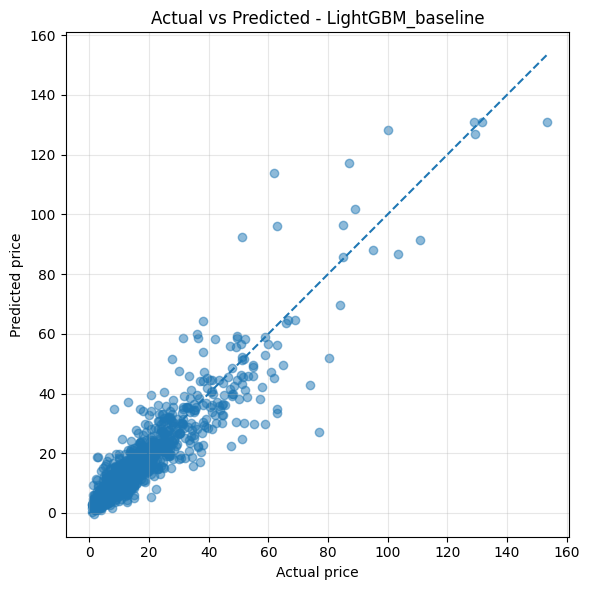

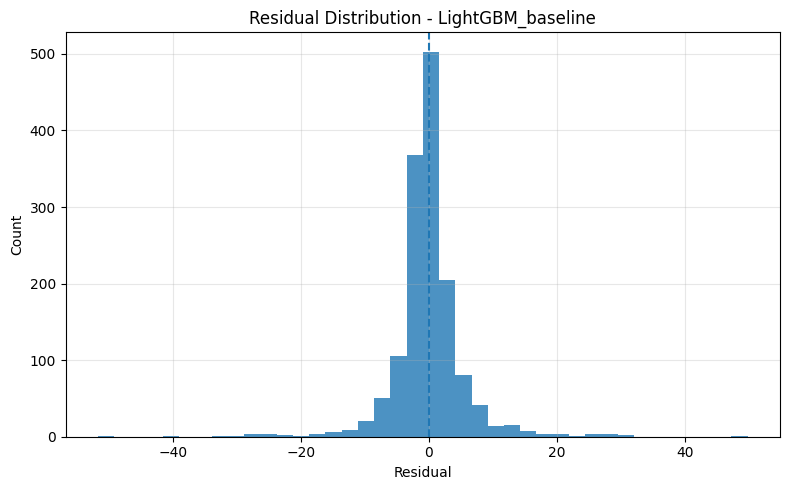

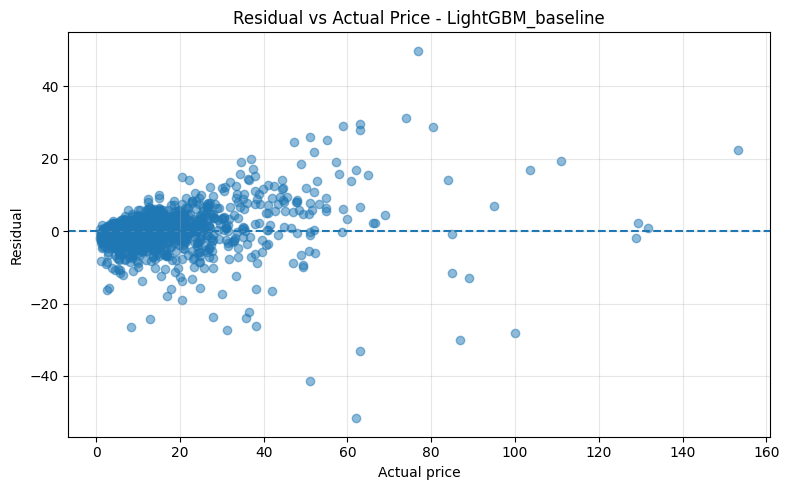

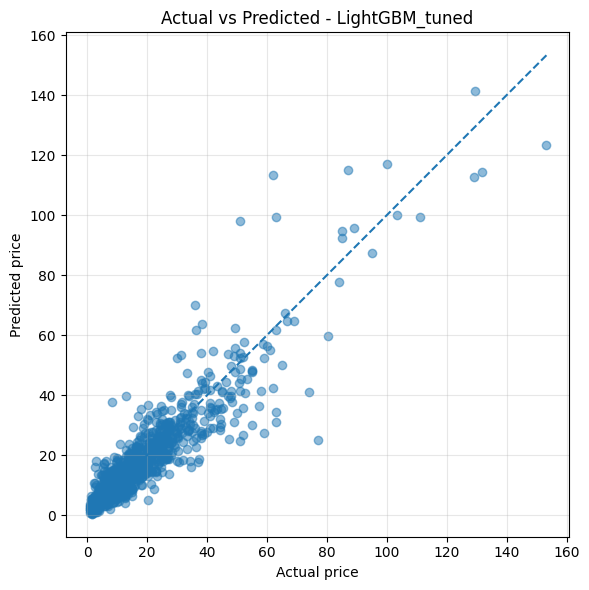

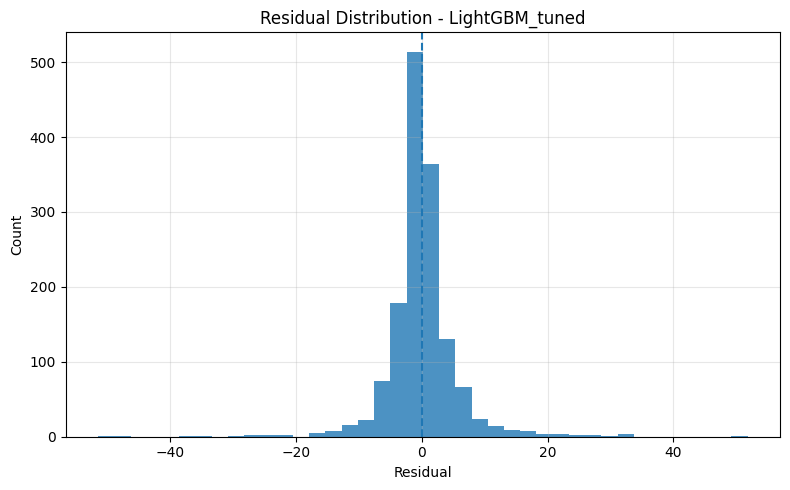

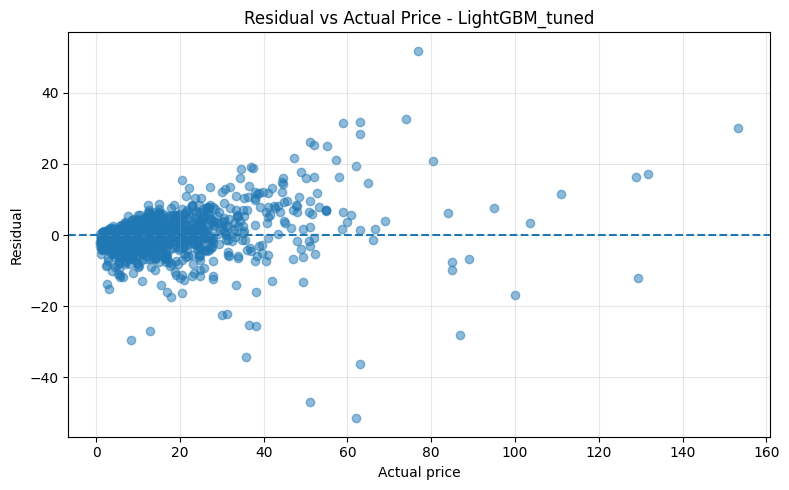

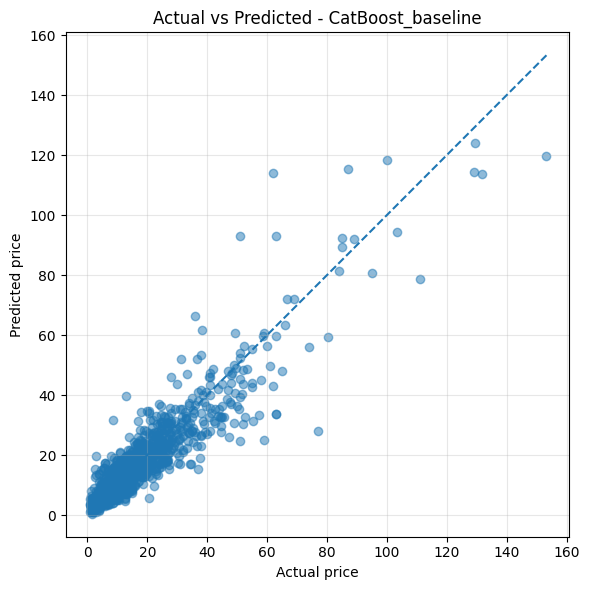

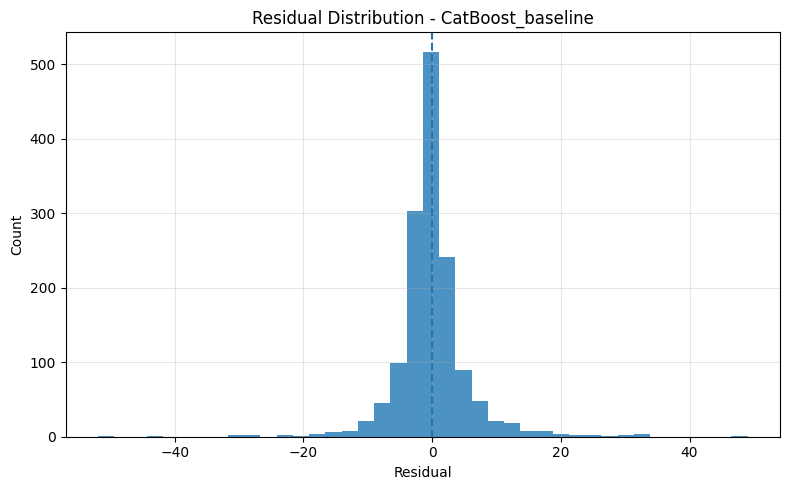

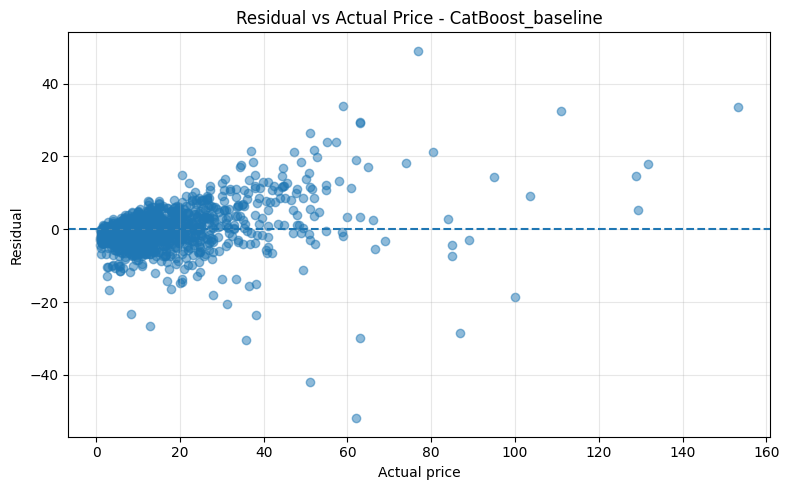

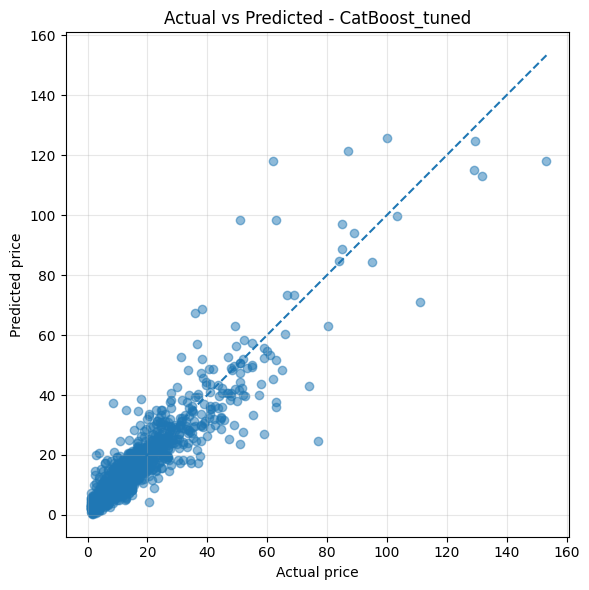

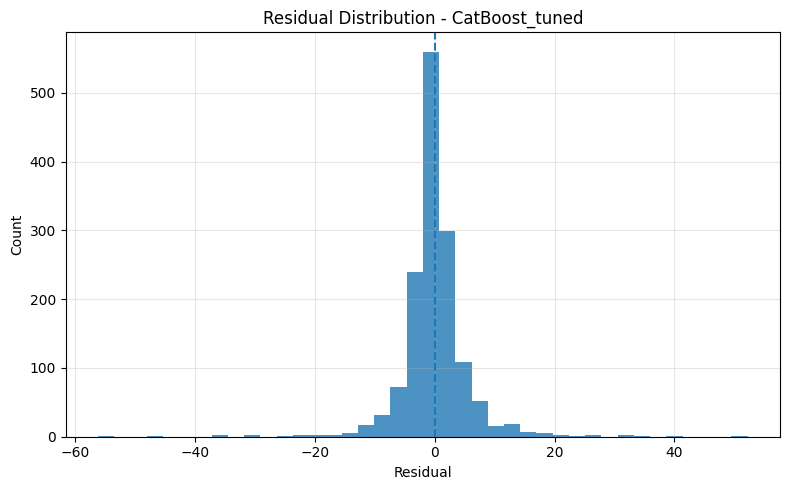

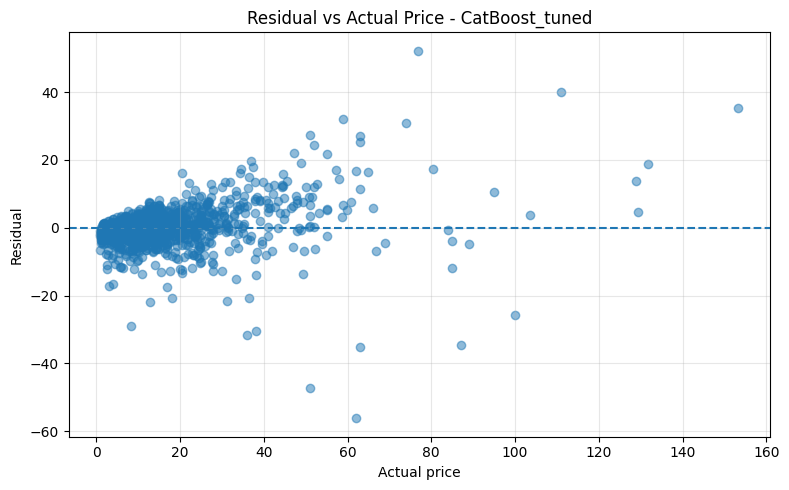

In [14]:
def plot_actual_vs_predicted(pred_df, model_label):
    plot_df = pred_df[pred_df["model_label"] == model_label].copy()

    plt.figure(figsize=(6, 6))
    plt.scatter(plot_df["actual_price"], plot_df["predicted_price"], alpha=0.5)

    min_val = min(plot_df["actual_price"].min(), plot_df["predicted_price"].min())
    max_val = max(plot_df["actual_price"].max(), plot_df["predicted_price"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.title(f"Actual vs Predicted - {model_label}")
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    path = EVAL_PLOT_DIR / f"actual_vs_predicted_{model_label}.png"
    plt.savefig(path, dpi=150)
    plt.show()


def plot_residual_distribution(pred_df, model_label):
    plot_df = pred_df[pred_df["model_label"] == model_label].copy()

    plt.figure(figsize=(8, 5))
    plt.hist(plot_df["residual"], bins=40, alpha=0.8)
    plt.axvline(0, linestyle="--")

    plt.title(f"Residual Distribution - {model_label}")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    path = EVAL_PLOT_DIR / f"residual_distribution_{model_label}.png"
    plt.savefig(path, dpi=150)
    plt.show()


def plot_residual_vs_actual(pred_df, model_label):
    plot_df = pred_df[pred_df["model_label"] == model_label].copy()

    plt.figure(figsize=(8, 5))
    plt.scatter(plot_df["actual_price"], plot_df["residual"], alpha=0.5)
    plt.axhline(0, linestyle="--")

    plt.title(f"Residual vs Actual Price - {model_label}")
    plt.xlabel("Actual price")
    plt.ylabel("Residual")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    path = EVAL_PLOT_DIR / f"residual_vs_actual_{model_label}.png"
    plt.savefig(path, dpi=150)
    plt.show()


for model_label in final_predictions_df["model_label"].unique():
    plot_actual_vs_predicted(final_predictions_df, model_label)
    plot_residual_distribution(final_predictions_df, model_label)
    plot_residual_vs_actual(final_predictions_df, model_label)

## Feature Importance

In [15]:
def get_feature_importance(model, feature_names, model_label):
    if not hasattr(model, "feature_importances_"):
        return None

    importance = model.feature_importances_

    if len(importance) != len(feature_names):
        print(
            f"Feature importance length mismatch for {model_label}: "
            f"{len(importance)} vs {len(feature_names)}"
        )
        return None

    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": importance,
            "model_label": model_label,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


fi_frames = []

for model_label, model in candidate_models.items():
    fi_df = get_feature_importance(model, feature_names, model_label)
    if fi_df is not None:
        fi_frames.append(fi_df)

if fi_frames:
    feature_importance_df = pd.concat(fi_frames, axis=0).reset_index(drop=True)
else:
    feature_importance_df = pd.DataFrame()

display(feature_importance_df.head(40))

feature_importance_df.to_csv(
    EVAL_METRIC_DIR / "feature_importance.csv",
    index=False,
)

,feature,importance,model_label
0,screen_size_inch,"1,734.0000",LightGBM_baseline
1,cpu_intel_generation_ord,"1,176.0000",LightGBM_baseline
2,ram_storage_product_scaled,"1,160.0000",LightGBM_baseline
3,cpu_tier_encoded,"1,054.0000",LightGBM_baseline
4,gpu_tier_ord_filled,887.0000,LightGBM_baseline
5,storage_gb,827.0000,LightGBM_baseline
6,ram_gb,737.0000,LightGBM_baseline
7,memory_storage_score,720.0000,LightGBM_baseline
8,cpu_family_ord_filled,651.0000,LightGBM_baseline
9,cpu_suffix_power_ord_filled,613.0000,LightGBM_baseline


## Optional SHAP For Selected Model

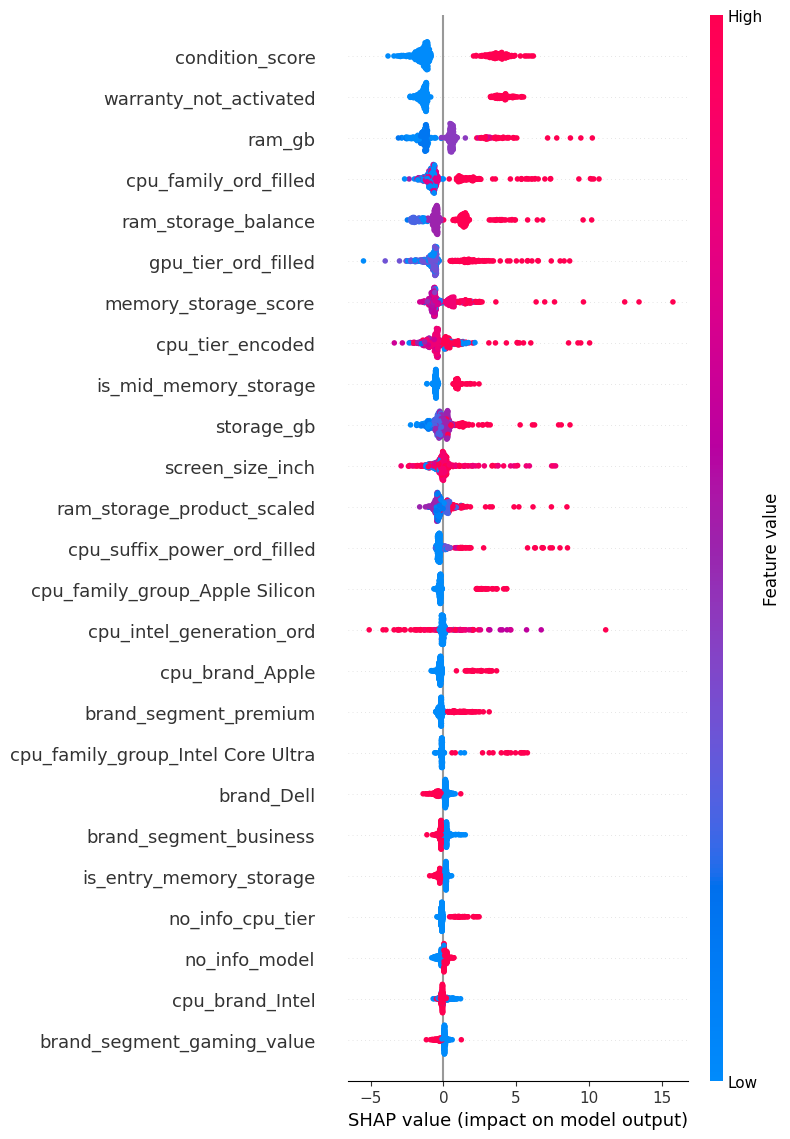

Saved SHAP summary plot to: Y:\Python\Laptop-Price-Prediction\artifacts\final_model_evaluation\plots\shap_summary_CatBoost_tuned.png


In [16]:
try:
    import shap

    selected_model = candidate_models[selected_model_label]

    sample_X = X_test.sample(
        n=min(500, len(X_test)),
        random_state=RANDOM_STATE,
    )

    explainer = shap.TreeExplainer(selected_model)
    shap_values = explainer.shap_values(sample_X)

    shap.summary_plot(
        shap_values,
        sample_X,
        max_display=25,
        show=False,
    )

    shap_plot_path = EVAL_PLOT_DIR / f"shap_summary_{selected_model_label}.png"
    plt.tight_layout()
    plt.savefig(shap_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved SHAP summary plot to: {shap_plot_path}")

except Exception as e:
    print(f"SHAP analysis skipped due to error: {e}")

## Final Model Decision

In [17]:
HOLDOUT_RMSE_TOLERANCE_PCT = 3.0

selected_rmse = selected_metrics["rmse"]
best_holdout_rmse = best_holdout_metrics["rmse"]

rmse_gap_pct = (
    (selected_rmse - best_holdout_rmse)
    / best_holdout_rmse
    * 100
)

if selected_model_label == best_holdout_label:
    recommended_model_label = selected_model_label
    decision_status = "confirm_selected_model"
    decision_reason = "Selected model is also the best model on holdout RMSE."
elif rmse_gap_pct <= HOLDOUT_RMSE_TOLERANCE_PCT:
    recommended_model_label = selected_model_label
    decision_status = "keep_kfold_selected_model"
    decision_reason = (
        "Selected model is not best on holdout RMSE, but the gap is within tolerance. "
        "Keep KFold-selected model because it is more stable across folds."
    )
else:
    recommended_model_label = best_holdout_label
    decision_status = "switch_to_holdout_challenger"
    decision_reason = (
        "Selected model underperforms the best holdout model beyond tolerance. "
        "Switching to holdout challenger is recommended, but this should be reviewed with segment diagnostics."
    )

final_decision = {
    "kfold_selected_model": selected_model_label,
    "best_holdout_model": best_holdout_label,
    "recommended_final_model": recommended_model_label,
    "decision_status": decision_status,
    "decision_reason": decision_reason,
    "holdout_rmse_tolerance_pct": HOLDOUT_RMSE_TOLERANCE_PCT,
    "selected_holdout_rmse": float(selected_rmse),
    "best_holdout_rmse": float(best_holdout_rmse),
    "rmse_gap_pct": float(rmse_gap_pct),
}

final_decision_df = pd.DataFrame([final_decision])

display(final_decision_df)

final_decision_df.to_csv(
    EVAL_REPORT_DIR / "final_model_decision.csv",
    index=False,
)

with open(EVAL_REPORT_DIR / "final_model_decision.json", "w", encoding="utf-8") as f:
    json.dump(final_decision, f, indent=2, ensure_ascii=False)

,kfold_selected_model,best_holdout_model,recommended_final_model,decision_status,decision_reason,holdout_rmse_tolerance_pct,selected_holdout_rmse,best_holdout_rmse,rmse_gap_pct
0,CatBoost_tuned,LightGBM_baseline,CatBoost_tuned,keep_kfold_selected_model,"Selected model is not best on holdout RMSE, bu...",3.0000,5.9127,5.7849,2.2101


## Evaluation Artifact Format

The evaluation model artifact is exported as a `.joblib` file because this project uses Python tree-based models such as LightGBM and CatBoost. Joblib is suitable for loading sklearn-compatible estimators in Python for audit and reproducibility.

This artifact is not the final production model. It was trained on the 80% training split so the 20% holdout can remain independent for final evaluation.

## Export Evaluation Model Artifact

The model exported in this notebook is still the 80% training-split model used for holdout evaluation. It is saved only as an evaluation artifact.

The true production model will be created in notebook 15 after retraining the final selected configuration on 100% of the labeled dataset.

In [18]:
evaluation_model = candidate_models[recommended_model_label]

evaluation_model_path = EVAL_MODEL_DIR / "selected_evaluation_model.joblib"
evaluation_metadata_path = EVAL_MODEL_DIR / "selected_evaluation_model_metadata.json"

joblib.dump(evaluation_model, evaluation_model_path)

evaluation_metadata = {
    "model_file": str(evaluation_model_path),
    "model_label": recommended_model_label,
    "training_scope": "train_split_80_percent",
    "usage": "holdout_evaluation_only",
    "not_for_final_web_deployment": True,
    "target": TARGET_COL,
    "n_features": len(feature_names),
    "source_notebook": "14_final_model_evaluation.ipynb",
    "next_step": (
        "Notebook 15 should retrain this selected model configuration "
        "on 100% of the dataset and export the true production model to root/models/."
    ),
}

with open(evaluation_metadata_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_metadata, f, indent=2, ensure_ascii=False)

print(f"Saved evaluation model artifact to: {evaluation_model_path}")
print(f"Saved evaluation metadata to: {evaluation_metadata_path}")

Saved evaluation model artifact to: Y:\Python\Laptop-Price-Prediction\artifacts\final_model_evaluation\models\selected_evaluation_model.joblib
Saved evaluation metadata to: Y:\Python\Laptop-Price-Prediction\artifacts\final_model_evaluation\models\selected_evaluation_model_metadata.json


## Evaluation Model Artifact Smoke Test

In [19]:
loaded_evaluation_model = joblib.load(evaluation_model_path)

sample_X = X_test.iloc[:5].copy()
sample_pred = loaded_evaluation_model.predict(sample_X)

evaluation_smoke_test_df = pd.DataFrame({
    "sample_index": sample_X.index,
    "prediction": sample_pred,
})

display(evaluation_smoke_test_df)

evaluation_smoke_test_df.to_csv(
    EVAL_REPORT_DIR / "evaluation_model_smoke_test_predictions.csv",
    index=False,
)

print("Evaluation model artifact smoke test passed.")

,sample_index,prediction
0,2529,7.4278
1,4044,4.7529
2,3208,8.6264
3,7104,22.1819
4,6154,34.9564


Evaluation model artifact smoke test passed.


## Artifact Check

In [20]:
expected_files = [
    EVAL_METRIC_DIR / "final_holdout_metrics.csv",
    EVAL_METRIC_DIR / "selected_vs_challenger.csv",
    EVAL_METRIC_DIR / "segment_holdout_metrics.csv",
    EVAL_METRIC_DIR / "over_under_prediction_summary.csv",
    EVAL_METRIC_DIR / "feature_importance.csv",
    EVAL_PRED_DIR / "final_holdout_predictions.csv",
    EVAL_PRED_DIR / "top_error_cases.csv",
    EVAL_PRED_DIR / "top_error_cases_with_context.csv",
    EVAL_REPORT_DIR / "final_model_decision.csv",
    EVAL_REPORT_DIR / "final_model_decision.json",
    EVAL_REPORT_DIR / "evaluation_model_smoke_test_predictions.csv",
    EVAL_MODEL_DIR / "selected_evaluation_model.joblib",
    EVAL_MODEL_DIR / "selected_evaluation_model_metadata.json",
]

artifact_rows = []

for path in expected_files:
    artifact_rows.append({
        "path": str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    })

artifact_check_df = pd.DataFrame(artifact_rows)
display(artifact_check_df)

missing_artifacts = artifact_check_df[~artifact_check_df["exists"]]

if not missing_artifacts.empty:
    raise FileNotFoundError(
        "Missing artifacts:\n"
        + "\n".join(missing_artifacts["path"].tolist())
    )

print("All final evaluation artifacts are present.")

,path,exists,size_bytes
0,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,770
1,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,304
2,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,3218
3,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,830
4,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,16300
5,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,595981
6,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,8255
7,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,9354
8,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,456
9,Y:\Python\Laptop-Price-Prediction\artifacts\fi...,True,528


All final evaluation artifacts are present.


## Final Conclusion

This notebook completed the final holdout evaluation stage.

The selected model from notebook 13 was compared against the strongest holdout challenger using holdout metrics, segment-level errors, large-error cases, residual diagnostics, and feature importance.

The model saved in this notebook is an evaluation artifact only. It was trained on the 80% training split and should not be treated as the final production model for the web/backend.

The true production model will be created in notebook 15 by retraining the final selected configuration on 100% of the labeled dataset.

Notebook 15 should export the final full-data model to:

`models/final_laptop_price_model.joblib`

along with:

`models/final_laptop_price_model_metadata.json`

and:

`models/final_laptop_price_feature_schema.json`